In [1]:
import requests

In [2]:
api_key = "5834b8980b682a8934c80ac003db693a"

In [3]:
url = "https://api.themoviedb.org/3/movie/popular"

params = {
    "api_key": api_key
}

response = requests.get(url, params=params)

print(response.status_code)

200


In [4]:
data = response.json()

data["results"][:2]

[{'adult': False,
  'backdrop_path': '/qeQJx07rK2xm8SD2sJxFKhE7gs0.jpg',
  'genre_ids': [878, 28, 12],
  'id': 969681,
  'title': 'Spider-Man: Brand New Day',
  'original_language': 'en',
  'original_title': 'Spider-Man: Brand New Day',
  'overview': "Fighting crime full-time as Spider-Man in a world that doesn't remember him—and the pressure of seeing his old friends move on without him—sparks a change in Peter Parker he may not have the power to control. But that transformation might also be the only thing that can stop a shocking new threat to the city and those he loves - a powerful villain no one can even see.",
  'popularity': 766.2638,
  'poster_path': '/bjiS5ipwxb9JFy3XRRN4OAilSeX.jpg',
  'release_date': '2026-07-29',
  'softcore': False,
  'video': False,
  'vote_average': 7.85,
  'vote_count': 2675},
 {'adult': False,
  'backdrop_path': '/7GOW6jod9lLurW5utokAatxg7ql.jpg',
  'genre_ids': [35, 12, 10751],
  'id': 1204680,
  'title': 'Coyote vs. Acme',
  'original_language': 'en

In [5]:
movie_id = data["results"][0]["id"]

details_url = f"https://api.themoviedb.org/3/movie/{movie_id}"

details_response = requests.get(details_url, params={"api_key": api_key})

movie_details = details_response.json()

movie_details

{'adult': False,
 'backdrop_path': '/7iwUUcKURMT7aKfCwMy6YnGtchD.jpg',
 'belongs_to_collection': {'id': 531241,
  'name': 'Spider-Man (MCU) Collection',
  'poster_path': '/yeba3Y820OjApZO9aJevDsNeMEd.jpg',
  'backdrop_path': '/AvnqpRwlEaYNVL6wzC4RN94EdSd.jpg'},
 'budget': 225000000,
 'genres': [{'id': 878, 'name': 'Science Fiction'},
  {'id': 28, 'name': 'Action'},
  {'id': 12, 'name': 'Adventure'}],
 'homepage': 'https://spidermanbrandnewday.movie',
 'id': 969681,
 'imdb_id': 'tt22084616',
 'origin_country': ['US'],
 'original_language': 'en',
 'original_title': 'Spider-Man: Brand New Day',
 'overview': "Fighting crime full-time as Spider-Man in a world that doesn't remember him—and the pressure of seeing his old friends move on without him—sparks a change in Peter Parker he may not have the power to control. But that transformation might also be the only thing that can stop a shocking new threat to the city and those he loves - a powerful villain no one can even see.",
 'popularity':

In [11]:
movies = []

for movie in data["results"][:20]:
    movie_id = movie["id"]

    details_url = f"https://api.themoviedb.org/3/movie/{movie_id}"
    details_response = requests.get(details_url, params={"api_key": api_key})
    details = details_response.json()

    movies.append({
        "title": details["title"],
        "budget": details["budget"],
        "revenue": details["revenue"],
        "rating": details["vote_average"],
        "release_date": details["release_date"]
    })

movies

[{'title': 'Spider-Man: Brand New Day',
  'budget': 225000000,
  'revenue': 2451171000,
  'rating': 7.849,
  'release_date': '2026-07-29'},
 {'title': 'Coyote vs. Acme',
  'budget': 72000000,
  'revenue': 64997869,
  'rating': 7.617,
  'release_date': '2026-08-20'},
 {'title': 'Colony',
  'budget': 0,
  'revenue': 0,
  'rating': 8.08,
  'release_date': '2026-05-21'},
 {'title': 'The Odyssey',
  'budget': 250000000,
  'revenue': 1684432000,
  'rating': 8.007,
  'release_date': '2026-07-15'},
 {'title': 'Mutiny',
  'budget': 40000000,
  'revenue': 20824283,
  'rating': 6.428,
  'release_date': '2026-08-19'},
 {'title': 'Moana',
  'budget': 250000000,
  'revenue': 308159595,
  'rating': 7.2,
  'release_date': '2026-07-08'},
 {'title': 'The Mongoose',
  'budget': 0,
  'revenue': 0,
  'rating': 0.0,
  'release_date': '2026-10-30'},
 {'title': 'Drawn Together',
  'budget': 0,
  'revenue': 0,
  'rating': 6.563,
  'release_date': '2026-09-09'},
 {'title': 'Mayday',
  'budget': 0,
  'revenue': 

In [12]:
import pandas as pd

df = pd.DataFrame(movies)

df

,title,budget,revenue,rating,release_date
0,Spider-Man: Brand New Day,225000000,2451171000,7.849,2026-07-29
1,Coyote vs. Acme,72000000,64997869,7.617,2026-08-20
2,Colony,0,0,8.080,2026-05-21
3,The Odyssey,250000000,1684432000,8.007,2026-07-15
4,Mutiny,40000000,20824283,6.428,2026-08-19
5,Moana,250000000,308159595,7.200,2026-07-08
6,The Mongoose,0,0,0.000,2026-10-30
7,Drawn Together,0,0,6.563,2026-09-09
8,Mayday,0,0,7.940,2026-09-03
9,The Runner,0,0,6.800,2026-09-03


In [13]:
print(df.shape)

print((df["budget"] == 0).sum())
print((df["revenue"] == 0).sum())

(20, 5)
12
12


In [14]:
clean_df = df[(df["budget"] > 0) & (df["revenue"] > 0)]

clean_df

,title,budget,revenue,rating,release_date
0,Spider-Man: Brand New Day,225000000,2451171000,7.849,2026-07-29
1,Coyote vs. Acme,72000000,64997869,7.617,2026-08-20
3,The Odyssey,250000000,1684432000,8.007,2026-07-15
4,Mutiny,40000000,20824283,6.428,2026-08-19
5,Moana,250000000,308159595,7.200,2026-07-08
13,Toy Story 5,250000000,1136476240,8.354,2026-06-17
14,Obsession,750000,513852715,8.190,2026-05-13
17,The End of Oak Street,80000000,117234000,6.337,2026-08-12


In [15]:
print(clean_df.shape)

(8, 5)


In [16]:
all_movies = []

for page in range(1, 6):
    url = "https://api.themoviedb.org/3/movie/popular"

    params = {
        "api_key": api_key,
        "page": page
    }

    response = requests.get(url, params=params)
    page_data = response.json()

    all_movies.extend(page_data["results"])

print(len(all_movies))

100


In [17]:
movies = []

for movie in all_movies:
    movie_id = movie["id"]

    details_url = f"https://api.themoviedb.org/3/movie/{movie_id}"
    details_response = requests.get(details_url, params={"api_key": api_key})
    details = details_response.json()

    movies.append({
        "title": details["title"],
        "budget": details["budget"],
        "revenue": details["revenue"],
        "rating": details["vote_average"],
        "release_date": details["release_date"]
    })

print(len(movies))

100


In [18]:
df = pd.DataFrame(movies)

clean_df = df[(df["budget"] > 0) & (df["revenue"] > 0)]

print(df.shape)
print(clean_df.shape)

(100, 5)
(62, 5)


In [19]:
clean_df.to_csv("tmdb_movies_clean.csv", index=False)

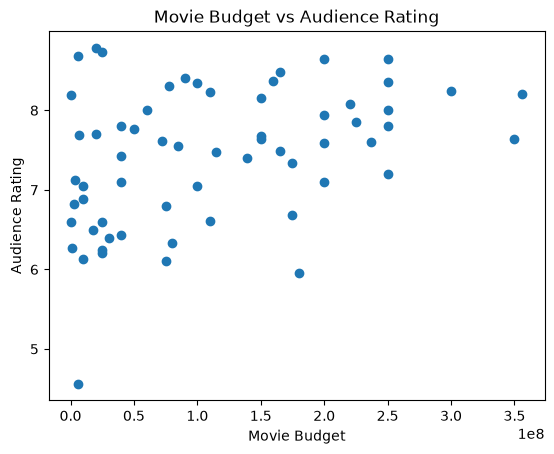

In [24]:
plt.scatter(clean_df["budget"], clean_df["rating"])
plt.xlabel("Movie Budget")
plt.ylabel("Audience Rating")
plt.title("Movie Budget vs Audience Rating")

plt.savefig("budget_vs_rating.png", bbox_inches="tight")
plt.show()

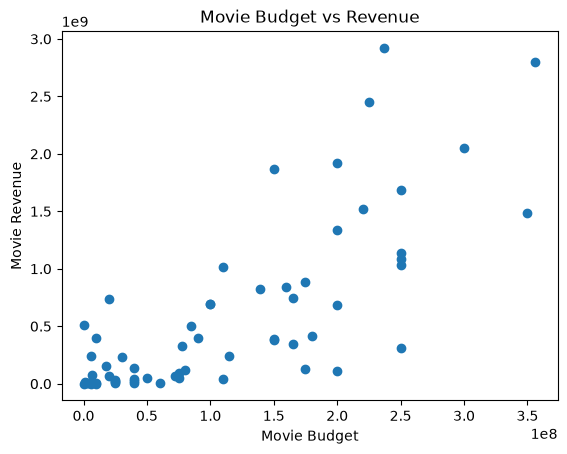

In [25]:
plt.scatter(clean_df["budget"], clean_df["revenue"])
plt.xlabel("Movie Budget")
plt.ylabel("Movie Revenue")
plt.title("Movie Budget vs Revenue")

plt.savefig("budget_vs_revenue.png", bbox_inches="tight")
plt.show()

In [22]:
print(clean_df["budget"].corr(clean_df["rating"]))
print(clean_df["budget"].corr(clean_df["revenue"]))

0.37699561494009637
0.7626670859647117


In [23]:
print(clean_df["budget"].corr(clean_df["rating"]))
print(clean_df["budget"].corr(clean_df["revenue"]))

0.37699561494009637
0.7626670859647117
